<h1 align="center"><b>Regresión Lineal con Python - Sklearn</b></h1> 

### **Definición**

La regresión lineal es un modelo estadístico que describe la relación entre una variable dependiente $y$ y un conjunto de variables independientes $X = (x_1, x_2, \dots, x_p)$.

El modelo se define como:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p + \varepsilon
$$

donde:

- $\beta_0$ es el intercepto
- $\beta_i$ son los coeficientes del modelo
- $\varepsilon$ es el término de error aleatorio

---

### **Estimación por Mínimos Cuadrados Ordinarios (OLS)**

El objetivo es estimar los parámetros $\beta$ minimizando la suma de los errores al cuadrado:

$$
\min_{\beta} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

En forma matricial:

$$
\min_{\beta} (y - X\beta)^T (y - X\beta)
$$

La solución analítica es:

$$
\hat{\beta} = (X^T X)^{-1} X^T y
$$

Siempre que $X^T X$ sea invertible.

---

### **Interpretación del Modelo**

Cada coeficiente $\beta_j$ representa el cambio esperado en $y$ ante un incremento unitario en $x_j$, manteniendo constantes las demás variables.

El modelo predice:

$$
\hat{y} = X \hat{\beta}
$$

---

### **Supuestos del Modelo Lineal**

Para que el modelo sea válido, se asume:

- Linealidad: la relación entre $X$ y $y$ es lineal

- Independencia de los errores

- Homocedasticidad: varianza constante del error

- Normalidad del error: $\varepsilon \sim \mathcal{N}(0, \sigma^2)$

- No multicolinealidad perfecta

---

### **Enfoque de Machine Learning**

Desde la perspectiva de Machine Learning, la regresión lineal se utiliza como un modelo predictivo.

El objetivo principal es minimizar el error de predicción:

$$
\mathcal{L}(\beta) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Se prioriza:

- Capacidad predictiva

- Generalización

- Escalabilidad computacional

---

### **Enfoque Estadístico**

Desde la perspectiva estadística, el interés se centra en la inferencia sobre los parámetros.

Se estudia la distribución de:

$$
\hat{\beta} \sim \mathcal{N}(\beta, \sigma^2 (X^T X)^{-1})
$$

Esto permite construir:

- Intervalos de confianza

- Pruebas de hipótesis

- Estadísticos $t$ y $F$

---

### **Varianza del Estimador**

La matriz de varianza-covarianza es:

$$
\text{Var}(\hat{\beta}) = \sigma^2 (X^T X)^{-1}
$$

donde $\sigma^2$ se estima como:

$$
\hat{\sigma}^2 = \frac{1}{n - p - 1} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

---

### **Coeficiente de Determinación**

El coeficiente $R^2$ mide la proporción de la variabilidad explicada por el modelo:

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$

---

### **Diferencia Conceptual**

Existen dos enfoques principales:

- Enfoque predictivo: centrado en minimizar el error de predicción

- Enfoque inferencial: centrado en analizar y validar los parámetros

---

### **Comparación Conceptual**


- **Predicción:**
$$
\hat{y} = X \hat{\beta}
$$

- **Inferencia:**
$$
H_0: \beta_j = 0
$$

- **Estadístico de prueba:**
$$
t = \frac{\hat{\beta}_j}{SE(\hat{\beta}_j)}
$$

---

La regresión lineal es un modelo fundamental que puede ser interpretado desde dos perspectivas:


- Optimización numérica para predicción

- Modelo probabilístico para inferencia


Ambos enfoques comparten la misma base matemática, pero difieren en su propósito y uso práctico.

---

| Característica        | Scikit-Learn     | Statsmodels |
| --------------------- | ---------------- | ----------- |
| Enfoque               | Machine Learning | Estadístico |
| Predicción            | ✅ Excelente      | ✅ Buena     |
| Inferencia (p-values) | ❌ No             | ✅ Sí        |
| Facilidad de uso      | ✅ Muy alta       | Media       |
| Pipeline ML           | ✅ Sí             | ❌ No        |
| Interpretabilidad     | Básica           | Avanzada    |

---

### **Interpretación del modelo**

Los principales elementos que hay que interpretar en un modelo de regresión lineal son los coeficientes de los predictores:


- $\beta_0$ es la ordenada en el origen o \textit{intercept}, se corresponde con el valor esperado de la variable respuesta $y$ cuando todos los predictores son cero.
    
- $\beta_j$ los coeficientes de regresión parcial de cada predictor indican el cambio promedio esperado de la variable respuesta $y$ al incrementar en una unidad de la variable predictora $x_j$, manteniéndose constantes el resto de variables.


La magnitud de cada coeficiente parcial de regresión depende de las unidades en las que se mida la variable predictora a la que corresponde, por lo que su magnitud no está asociada con la importancia de cada predictor.

Para poder determinar qué impacto tienen en el modelo cada una de las variables, se emplean los coeficientes parciales estandarizados, que se obtienen al estandarizar (sustraer la media y dividir entre la desviación estándar) las variables predictoras previo ajuste del modelo. En este caso, $\beta_0$ se corresponde con el valor esperado de la variable respuesta cuando todos los predictores se encuentran en su valor promedio, y $\beta_j$ el cambio promedio esperado de la variable respuesta al incrementar en una desviación estándar la variable predictora $x_j$, manteniéndose constantes el resto de variables.

Si bien los coeficientes de regresión suelen ser el primer objetivo de la interpretación de un modelo lineal, existen muchos otros aspectos (significancia del modelo en su conjunto, significancia de los predictores, condición de normalidad...). Estos últimos suelen ser tratados con poca detalle cuando el único objetivo del modelo es realizar predicciones, sin embargo, son muy relevantes si se quiere realizar inferencia, es decir, explicar las relaciones entre los predictores y la variable respuesta. A lo largo de este documento se irán introduciendo cada uno de ellos.

---

### **Significado "Lineal"**

El término "lineal" en los modelos de regresión hace referencia al hecho de que los parámetros se incorporan en la ecuación de forma lineal, no a que necesariamente la relación entre cada predictor y la variable respuesta tenga que seguir un patrón lineal.

La siguiente ecuación muestra un modelo lineal en el que el predictor $x_1$ no es lineal respecto a $y$:


$$y = \beta_0 + \beta_1 x_1 + \beta_2 \log(x_1) + \epsilon$$

<p align="center">
   <img src="img/noline.png" width="600" height="300">
</p>

---

### **Bondad de ajuste del modelo**

Una vez ajustado el modelo, es necesario verificar su utilidad ya que, aun siendo la línea que mejor se ajusta a las observaciones de entre todas las posibles, puede tener un gran error. Las métricas más utilizadas para medir la calidad del ajuste son: el error estándar de los residuos y el coeficiente de determinación $R^2$.

### **Error estándar de los residuos (Residual Standard Error, RSE)**

Mide la desviación promedio de cualquier punto estimado por el modelo respecto de la recta de regresión. Tiene las mismas unidades que la variable respuesta. Una forma de saber si el valor del $RSE$ es elevado consiste en dividirlo entre el valor medio de la variable respuesta, obteniendo así un % de la desviación.

$$RSE = \sqrt{\frac{1}{n - p - 1} RSS}$$

En modelos lineales simples, dado que hay un único predictor ($n - p - 1 = n - 2$).

### **Coeficiente de determinación $R^2$**

$R^2$ describe la proporción de varianza de la variable respuesta explicada por el modelo y relativa a la varianza total. Su valor está acotado entre 0 y 1. Al ser adimensional, presenta la ventaja frente al $RSE$ de ser más fácil de interpretar.

$$R^2 = \frac{\text{Suma de cuadrados totales - Suma de cuadrados residuales}}{\text{Suma de cuadrados totales}}$$

$$R^2 = 1 - \frac{\text{Suma de cuadrados residuales}}{\text{Suma de cuadrados totales}}$$

$$R^2 = 1 - \frac{\sum (\hat{y}_i - y_i)^2}{\sum (y_i - \bar{y})^2}$$

En los modelos de regresión lineal simple el valor de $R^2$ se corresponde con el cuadrado del **coeficiente de correlación de Pearson ($r$)** entre $x$ e $y$, no siendo así en regresión múltiple.

En los modelos lineales múltiples, cuantos más predictores se incluyan en el modelo, mayor es el valor de $R^2$. Esto es así ya que, por poco que sea, cada predictor va a explicar una parte de la variabilidad observada en $y$. Es por esto que $R^2$ no puede utilizarse para comparar modelos con distinto número de predictores.

$R^2_{\text{ajustado}}$ introduce una penalización al valor de $R^2$ por cada predictor que se añade al modelo. El valor de la penalización depende del número de predictores utilizados y del tamaño de la muestra, es decir, del número de grados de libertad. Cuanto mayor es el tamaño de la muestra, más predictores se pueden incorporar en el modelo. $R^2_{\text{ajustado}}$ permite encontrar el mejor modelo, aquel que consigue explicar mejor la variabilidad de $y$ con el menor número de predictores.

$$R^2_{\text{ajustado}} = 1 - \frac{SSE}{SST} \cdot \frac{n - 1}{n - p - 1} = R^2 - (1 - R^2) \cdot \frac{n - 1}{n - p - 1} = 1 - \frac{SSE / df_e}{SST / df_t}$$

Siendo $SSE$ la variabilidad explicada por el modelo (Sum of Squares Explained), $SST$ la variabilidad total de $y$ (Sum of Squares Total), $n$ el tamaño de la muestra y $p$ el número de predictores introducidos en el modelo.

---

### **Métricas de Desempeño**

1. **Mean Absolute Error (MAE):** Mide el error promedio absoluto entre los valores reales y predichos.

$$ MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$

**Interpretación**

- Está en las mismas unidades de la variable objetivo

- Penaliza todos los errores de forma lineal

---

2. **Root Mean Squared Error (RMSE):** Mide la raíz del promedio de los errores al cuadrado.

$$ RMSE = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }$$

**Interpretación**

- Penaliza más los errores grandes

- Está en las mismas unidades que la variable objetivo

---

3. **Mean Absolute Percentage Error (MAPE):** Mide el error promedio en términos porcentuales.

$$ MAPE = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| $$

**Interpretación**

Se interpreta como porcentaje:

$$ MAPE = 0.10 \Rightarrow 10\% \text{ de error promedio} $$

---

### **Tabla Comparativa**

<div align="center">

| Métrica | Sensibilidad a outliers | Interpretación | Escala       |
|---------|-------------------------|----------------|--------------|
| MAE     | Baja                    | Fácil          | Original     |
| RMSE    | Alta                    | Media          | Original     |
| MAPE    | Media                   | Muy fácil (%)  | Relativa     |
| R²      | —                       | Global         | Adimensional |

</div>

---

### **Validación Cruzada (Cross-validation)**

La validación cruzada es un método estadístico utilizado para estimar la capacidad de los modelos de aprendizaje automático (machine learning). Se utiliza principalmente en el aprendizaje automático aplicado para estimar el desempeño de un algoritmo con datos no vistos previamente. La validación cruzada consiste en particionar un conjunto de datos en un grupo de entrenamiento y un grupo de prueba múltiples veces, para asegurar que el desempeño del modelo se evalúe de manera precisa.


**¿Por qué utilizar Validación Cruzada?**

La validación cruzada es crucial porque asegura que nuestro modelo no solo esté memorizando los datos de entrenamiento, sino que esté generalizando correctamente hacia datos nuevos. Este proceso ayuda a:

- Reducir el sobreajuste (overfitting) y el subajuste (underfitting).

- Proporcionar una estimación más precisa del desempeño del modelo.

- Garantizar que el modelo sea robusto y confiable.

<p align="center">
   <img src="img/CV3.png" width="900" height="400">
</p>

---

### **Método Tradicional vs Validación Cruzada**

El Método Tradicional (Train/Test Split) es como realizar un único examen final: divides tus datos una sola vez y confías en que esa partición sea representativa, lo cual es rápido pero riesgoso, ya que un "golpe de suerte" o una mala selección de datos puede sesgar los resultados. Por el contrario, la Validación Cruzada funciona como una serie de evaluaciones continuas; al rotar los datos de entrenamiento y prueba en múltiples iteraciones ($k$-folds), el modelo se enfrenta a todos los datos posibles. Esto reduce drásticamente el riesgo de sobreajuste y proporciona una métrica de error mucho más robusta y realista, asegurando que el modelo realmente haya aprendido a generalizar y no solo a memorizar un fragmento específico de la información.

<p align="center">
   <img src="img/CV4.png" width="900" height="400">
</p>

---

In [1]:
# ============ #
# 1. LIBRERÍAS #
# ============ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

In [2]:
# =================== #
# 2. LECTURA DE RUTAS #
# =================== #

mainpath= "/Users/duvancatano/Documents/Data_Analytics_UdeA/ml-project/data/housing"
filename= "housing_dataset.csv"
fullpath= os.path.join(mainpath,filename)

In [3]:
# ================= #
# 3. CARGA DE DATOS #
# ================= #

data = pd.read_csv(fullpath, sep=",") # El separador es "," porque en el archivo .csv los valores están separados por coma
pd.set_option('display.max_columns', None) # Para mostrar todas las columnas del DataFrame sin truncar

In [4]:
# ========================= #
# 4. SELECCIÓN DE VARIABLES #
# ========================= #

df = data[[
 'municipio',
 'zona_urbana_rural',
 'tipo_de_vivienda',
 'area_total_m2',
 'habitaciones',
 'banos',
 'antiguedad_de_la_vivienda',
 'parqueaderos',
 'estrato',
 'distancia_al_centro_de_la_ciudad_km',
 'acceso_a_transporte_publico',
 'acceso_a_internet',
 'acceso_a_agua_potable',
 'acceso_a_gas',
 'acceso_a_credito',
 'valor_de_mercado_de_la_vivienda'
 ]]

In [5]:
# ============================== #
# 5. IDENTIFICACIÓN DE VARIABLES #
# ============================== #

cat_cols = [
    'municipio',
    'zona_urbana_rural',
    'tipo_de_vivienda',
    'acceso_a_transporte_publico',
    'acceso_a_internet',
    'acceso_a_agua_potable',
    'acceso_a_gas'
]

num_cols = [
    'area_total_m2', 
    'habitaciones', 
    'banos',
    'antiguedad_de_la_vivienda', 
    'parqueaderos',
    'estrato', 
    'distancia_al_centro_de_la_ciudad_km'
]

target = 'valor_de_mercado_de_la_vivienda'

In [6]:
# ================================================================================================================== #
# 4. ONE-HOT ENCODING (A las variables categóricas aplícales One-Hot Encoding, y a las numéricas déjalas como están) #
# ================================================================================================================== #
 
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [7]:
# ============================= #
# 5. MOSTRAR LA BASE CODIFICADA #
# ============================= #
 
X = df[cat_cols + num_cols]
X_encoded = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X_encoded_df = pd.DataFrame(X_encoded, columns=feature_names)
X_encoded_df.sample(20)

,cat__municipio_Bogotá,cat__municipio_Bucaramanga,cat__municipio_Cali,cat__municipio_Cartagena,cat__municipio_Manizales,cat__municipio_Medellín,cat__municipio_Pereira,cat__zona_urbana_rural_Urban,cat__tipo_de_vivienda_Farm,cat__tipo_de_vivienda_House,cat__acceso_a_transporte_publico_Yes,cat__acceso_a_internet_Yes,cat__acceso_a_agua_potable_Yes,cat__acceso_a_gas_Yes,num__area_total_m2,num__habitaciones,num__banos,num__antiguedad_de_la_vivienda,num__parqueaderos,num__estrato,num__distancia_al_centro_de_la_ciudad_km
5414,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,90.120903,4.0,1.0,50.0,1.0,1.0,5.311788
5116,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,119.829155,4.0,1.0,62.0,0.0,3.0,9.810547
2453,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,83.785652,5.0,3.0,31.0,2.0,3.0,12.819986
5694,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,76.023937,4.0,2.0,1.0,1.0,2.0,16.810838
5638,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,57.845791,4.0,2.0,61.0,1.0,3.0,6.658380
7133,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,89.162899,2.0,2.0,47.0,2.0,2.0,9.346761
6633,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,51.823730,3.0,1.0,51.0,1.0,3.0,3.292735
9667,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,101.133063,5.0,3.0,37.0,0.0,4.0,6.764091
6313,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,49.288045,2.0,1.0,17.0,0.0,3.0,2.532171
5718,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,143.343429,3.0,1.0,33.0,1.0,3.0,2.158863


In [8]:
# ============================================= #
# 6. MOSTRAR LAS COLUMNAS DE LA BASE CODIFICADA #
# ============================================= #
X_encoded_df.columns.tolist()

['cat__municipio_Bogotá',
 'cat__municipio_Bucaramanga',
 'cat__municipio_Cali',
 'cat__municipio_Cartagena',
 'cat__municipio_Manizales',
 'cat__municipio_Medellín',
 'cat__municipio_Pereira',
 'cat__zona_urbana_rural_Urban',
 'cat__tipo_de_vivienda_Farm',
 'cat__tipo_de_vivienda_House',
 'cat__acceso_a_transporte_publico_Yes',
 'cat__acceso_a_internet_Yes',
 'cat__acceso_a_agua_potable_Yes',
 'cat__acceso_a_gas_Yes',
 'num__area_total_m2',
 'num__habitaciones',
 'num__banos',
 'num__antiguedad_de_la_vivienda',
 'num__parqueaderos',
 'num__estrato',
 'num__distancia_al_centro_de_la_ciudad_km']

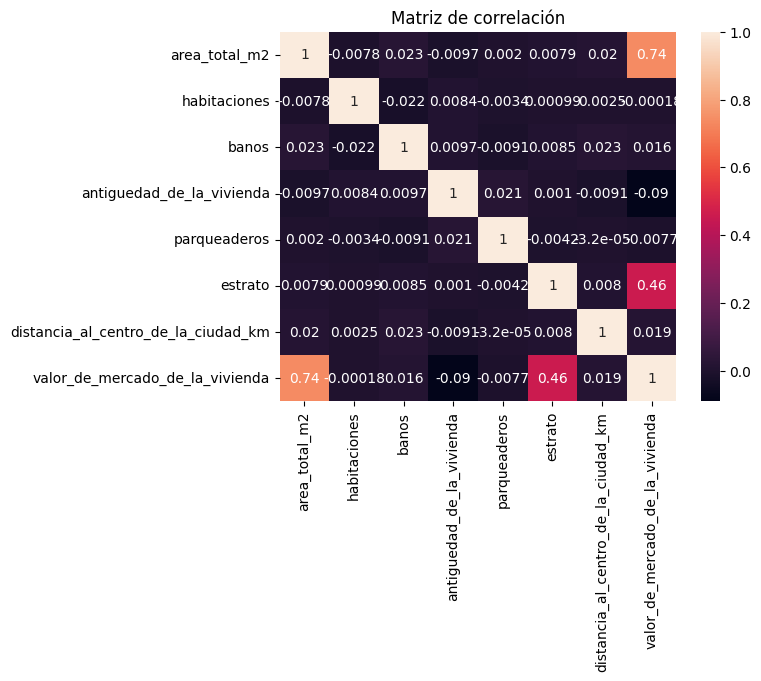

In [9]:
# ===================================================== #
# 7. ANÁLISIS DE CORRELACIÓN (Solo variables numéricas) #
# ===================================================== #

corr = df[num_cols + [target]].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Matriz de correlación")
plt.show()

In [10]:
# ========================= #
# 8. PARTICIÓN TRAIN / TEST #
# ========================= #

X = df[cat_cols + num_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# ====================== #
# 9. MODELO DE REGRESIÓN #
# ====================== #

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
# ============== #
# 10. EVALUACIÓN #
# ============== #

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("MAPE (%):", mape * 100)
print("R2:", r2)

MAE: 20.14323461588141
RMSE: 25.18391449169522
MAPE: 0.3555572743666488
MAPE (%): 35.55572743666488
R2: 0.7454805564866434


In [ ]:
# ======================================== #
# 10.1. DATAFRAME CON RESULTADOS Y ERRORES # 
# ======================================== #

# Asegurar formatos
X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_test_df = pd.Series(y_test).reset_index(drop=True)
y_pred_df = pd.Series(y_pred)

# Construir DataFrame final
df_resultados = X_test_df.copy()
df_resultados["y_real"] = y_test_df
df_resultados["y_pred"] = y_pred_df

df_resultados["error"] = df_resultados["y_real"] - df_resultados["y_pred"]
df_resultados["abs_error"] = df_resultados["error"].abs()

df_resultados.head()

,municipio,zona_urbana_rural,tipo_de_vivienda,acceso_a_transporte_publico,acceso_a_internet,acceso_a_agua_potable,acceso_a_gas,area_total_m2,habitaciones,banos,antiguedad_de_la_vivienda,parqueaderos,estrato,distancia_al_centro_de_la_ciudad_km,y_real,y_pred,error,abs_error
0,Bucaramanga,Urban,Farm,Yes,Yes,Yes,Yes,102.298516,2,2,2,2,3,4.025986,94.968276,119.096293,-24.128017,24.128017
1,Cartagena,Urban,House,Yes,Yes,Yes,No,25.619847,4,1,0,1,2,11.661312,67.173927,60.258659,6.915268,6.915268
2,Bucaramanga,Urban,House,Yes,Yes,Yes,No,64.633881,5,1,21,0,5,10.487736,112.867223,125.942491,-13.075269,13.075269
3,Barranquilla,Rural,Farm,Yes,Yes,Yes,Yes,52.314126,2,3,3,2,1,5.824907,59.118435,59.153738,-0.035304,0.035304
4,Cali,Rural,House,Yes,Yes,Yes,Yes,93.607070,3,3,9,2,1,10.412771,167.433376,82.891109,84.542267,84.542267


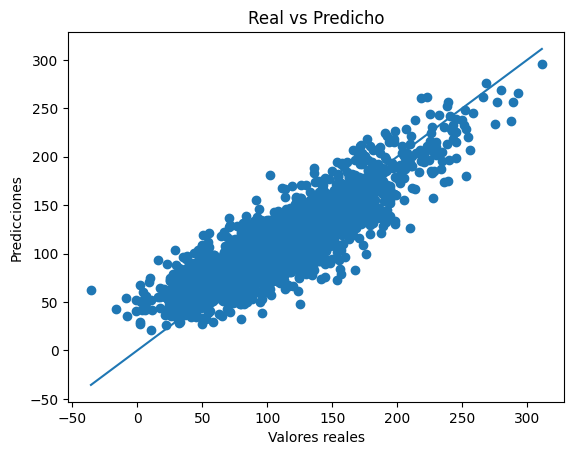

In [ ]:
# ====================== #
# 10.2. REAL VS PREDICHO #
# ====================== #

plt.scatter(df_resultados["y_real"], df_resultados["y_pred"])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho")

# Línea ideal
plt.plot(
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()],
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()]
)

plt.show()

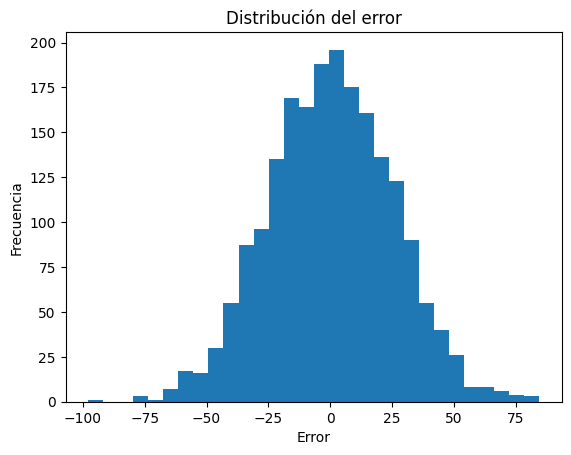

In [ ]:
# ============================= #
# 10.3. DISTRIBUCIÓN DE ERRORES #
# ============================= #

plt.hist(df_resultados["error"], bins=30)
plt.title("Distribución del error")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

In [32]:
# ====================== #
# 11. VALIDACIÓN CRUZADA #
# ====================== #

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'r2': 'r2'
}

cv_results = cross_validate(model, X, y, cv=10, scoring=scoring)

print("CV MAE:", -cv_results['test_mae'].mean())
print("CV RMSE:", -cv_results['test_rmse'].mean())
print("CV MAPE:", -cv_results['test_mape'].mean())
print("CV R2:", cv_results['test_r2'].mean())
print("FIT TIME:", cv_results['fit_time'].mean())
print("SCORE TIME:", cv_results['score_time'].mean())

CV MAE: 19.87671478042713
CV RMSE: 24.91231227231542
CV MAPE: 0.37577055619898264
CV R2: 0.752073004879691
FIT TIME: 0.009948205947875977
SCORE TIME: 0.0022912025451660156


In [34]:
# ========================== #
# RESULTADOS CRUDOS DE LA CV #
# ========================== #

(cv_results)

{'fit_time': array([0.01524115, 0.01200509, 0.00917602, 0.00979614, 0.00949502,
        0.00879097, 0.00839782, 0.00837803, 0.00957179, 0.00863004]),
 'score_time': array([0.00303674, 0.00262094, 0.0019803 , 0.00244784, 0.00248194,
        0.00193501, 0.00191832, 0.00204897, 0.00201011, 0.00243187]),
 'test_mae': array([-19.27677514, -19.58286644, -20.65810014, -20.12710534,
        -20.08476846, -20.26670026, -19.0933273 , -19.566304  ,
        -19.44622853, -20.6649722 ]),
 'test_rmse': array([-24.30718808, -24.43140272, -25.53339459, -25.29483868,
        -24.83364447, -25.27718439, -24.42066619, -24.58334103,
        -24.71546078, -25.7260018 ]),
 'test_mape': array([-0.27542837, -0.4517141 , -0.36802712, -0.52403072, -0.32285711,
        -0.60192543, -0.2767995 , -0.34036654, -0.2873748 , -0.30918188]),
 'test_r2': array([0.76392928, 0.73937258, 0.74987837, 0.75216584, 0.74739447,
        0.7447534 , 0.75516768, 0.75874294, 0.76168119, 0.74764429])}

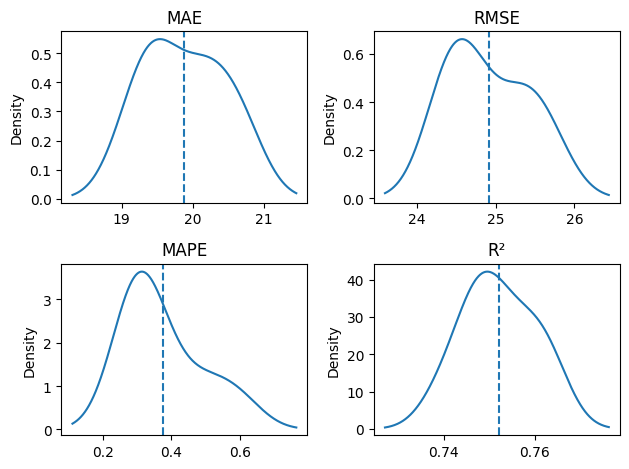

In [29]:
# ======================================= #
# VISUALIZACIÓN DE DENSIDADES POR MÉTRICA #
# ======================================= #

# DataFrame de métricas
cv_df = pd.DataFrame({
    'MAE': -cv_results['test_mae'],
    'RMSE': -cv_results['test_rmse'],
    'MAPE': -cv_results['test_mape'],
    'R2': cv_results['test_r2']
})

# Crear figura 2x2
fig, axes = plt.subplots(2, 2)

# MAE
cv_df['MAE'].plot(kind='kde', ax=axes[0, 0])
axes[0, 0].axvline(cv_df['MAE'].mean(), linestyle='--')
axes[0, 0].set_title("MAE")

# RMSE
cv_df['RMSE'].plot(kind='kde', ax=axes[0, 1])
axes[0, 1].axvline(cv_df['RMSE'].mean(), linestyle='--')
axes[0, 1].set_title("RMSE")

# MAPE
cv_df['MAPE'].plot(kind='kde', ax=axes[1, 0])
axes[1, 0].axvline(cv_df['MAPE'].mean(), linestyle='--')
axes[1, 0].set_title("MAPE")

# R2
cv_df['R2'].plot(kind='kde', ax=axes[1, 1])
axes[1, 1].axvline(cv_df['R2'].mean(), linestyle='--')
axes[1, 1].set_title("R²")

plt.tight_layout()
plt.show()

In [35]:
# ================================================== #
# 12. IMPORTANCIA DE VARIABLES MEDIANTE COEFICIENTES #
# ================================================== #

feature_names = model.named_steps['preprocessing'].get_feature_names_out()
coefficients = model.named_steps['regressor'].coef_

importance = pd.Series(coefficients, index=feature_names)
importance = importance.sort_values(key=abs, ascending=False)

print(importance.head(10))

num__estrato                      15.035580
cat__municipio_Manizales          -2.007965
cat__acceso_a_gas_Yes             -1.469950
cat__municipio_Pereira            -1.317352
cat__municipio_Cartagena          -1.023206
cat__tipo_de_vivienda_Farm         0.963076
cat__municipio_Bogotá             -0.923329
cat__acceso_a_agua_potable_Yes     0.721851
cat__municipio_Bucaramanga        -0.668432
num__area_total_m2                 0.603264
dtype: float64


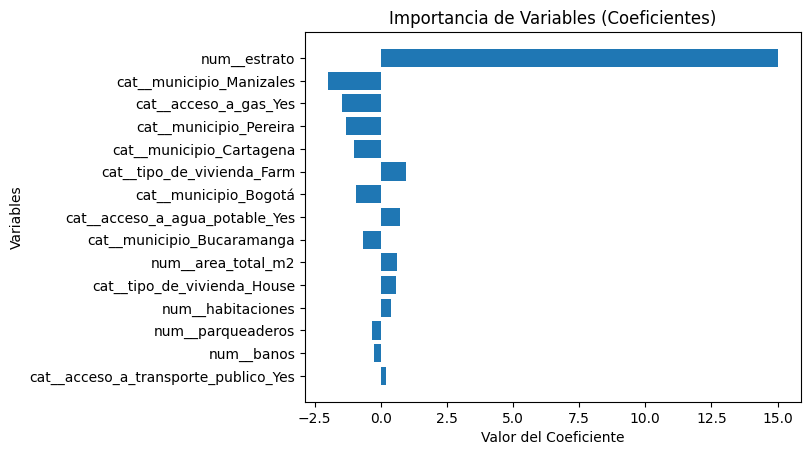

In [36]:
# =========================================================== #
# 13. GRAFICAR IMPORTANCIA DE VARIABLES MEDIANTE COEFICIENTES #
# =========================================================== #

# Extraer nombres de variables después del One-Hot
feature_names = model.named_steps['preprocessing'].get_feature_names_out()

# Coeficientes del modelo
coefficients = model.named_steps['regressor'].coef_

# Crear DataFrame de importancia
importance = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coefficients
})

# Ordenar por magnitud (importancia real)
importance['Importancia'] = importance['Coeficiente'].abs()
importance = importance.sort_values(by='Importancia', ascending=False)

# Tomar Top 15 (para que no quede ilegible)
top_n = 15
importance_top = importance.head(top_n)

# Gráfica
plt.figure()
plt.barh(importance_top['Variable'], importance_top['Coeficiente'])
plt.gca().invert_yaxis()
plt.title("Importancia de Variables (Coeficientes)")
plt.xlabel("Valor del Coeficiente")
plt.ylabel("Variables")
plt.show()

---

<h1 align="center"><b>Regresión Lineal - Statmodels</b></h1> 

In [ ]:
# ================ #
# Cargar Librarías #
# ================ #

import statsmodels.api as sm
import pandas as pd

In [ ]:
# ============================== #
# Codificación de la información #
# ============================== #

X_train_encoded = model.named_steps['preprocessing'].transform(X_train)
feature_names = model.named_steps['preprocessing'].get_feature_names_out()
X_train_encoded = pd.DataFrame(X_train_encoded, columns=feature_names)

In [ ]:
# ================= #
# Ajuste del modelo #
# ================= #

X_train_encoded = X_train_encoded.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Agregar constante
X_sm = sm.add_constant(X_train_encoded)

# Ajustar modelo
model_sm = sm.OLS(y_train, X_sm).fit()

print(model_sm.summary())

                                   OLS Regression Results                                  
Dep. Variable:     valor_de_mercado_de_la_vivienda   R-squared:                       0.755
Model:                                         OLS   Adj. R-squared:                  0.755
Method:                              Least Squares   F-statistic:                     1173.
Date:                             Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                                     16:04:47   Log-Likelihood:                -37035.
No. Observations:                             8000   AIC:                         7.411e+04
Df Residuals:                                 7978   BIC:                         7.427e+04
Df Model:                                       21                                         
Covariance Type:                         nonrobust                                         
                                               coef    std err          t      P

In [ ]:
# =================================================================== # 
# Diagnóstico errores (residuos) de las predicciones de entrenamiento #
# =================================================================== # 

residuals = model_sm.resid
fitted = model_sm.fittedvalues

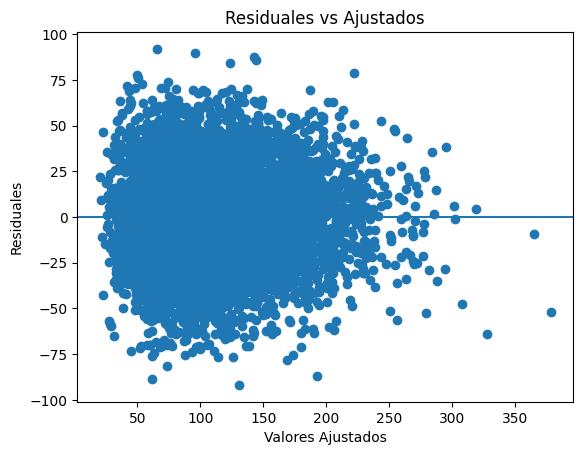

In [ ]:
# ================ #
# Gráfico residual #
# ================ #

plt.figure()
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Valores Ajustados")
plt.ylabel("Residuales")
plt.title("Residuales vs Ajustados")
plt.show()

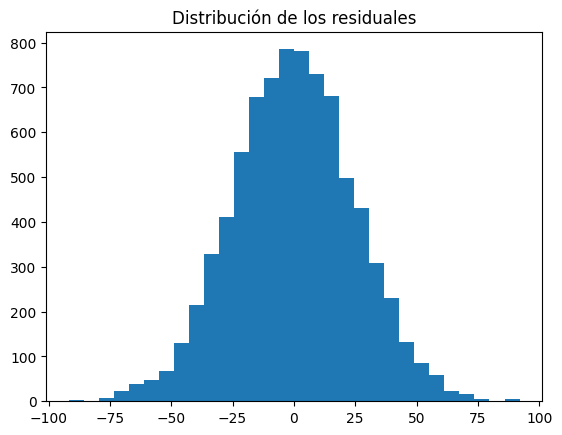

In [ ]:
# ================= #
# Densidad residual #
# ================= #

plt.figure()
plt.hist(residuals, bins=30)
plt.title("Distribución de los residuales")
plt.show()

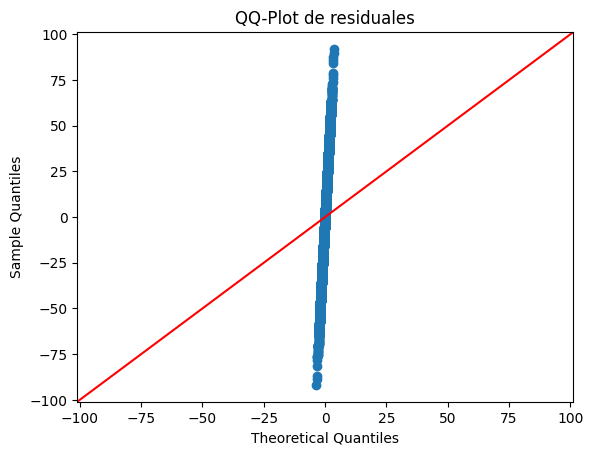

In [ ]:
# ================ #
# QQ plot Residual #
# ================ #

sm.qqplot(residuals, line='45')
plt.title("QQ-Plot de residuales")
plt.show()

In [ ]:
# ==================== #
# Prueba de normalidad #
# ==================== #

from statsmodels.stats.stattools import jarque_bera

jb_test = jarque_bera(residuals)

print("JB Statistic:", jb_test[0])
print("p-value:", jb_test[1])

JB Statistic: 0.5558310669847094
p-value: 0.7573607904336773


In [ ]:
# =========== #  
# Diagnóstico #  
# =========== #  

from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, model_sm.model.exog)

print("LM Statistic:", bp_test[0])
print("p-value:", bp_test[1])

LM Statistic: 23.563050716924216
p-value: 0.3147076859972135


---

## **Estabilidad**

El estudio de estabilidad de un modelo consiste en evaluar qué tan sensibles son sus resultados ante cambios en los datos de entrenamiento, por ejemplo, al comparar un modelo ajustado con $X_train$ frente a uno entrenado con el conjunto completo X. Para ello, se analizan tanto los coeficientes estimados como las predicciones generadas. 

En el caso de los coeficientes, se puede utilizar la diferencia relativa entre parámetros para identificar variaciones significativas, teniendo en cuenta que valores extremos pueden surgir cuando los coeficientes son cercanos a cero. No obstante, debido a transformaciones dentro de pipelines o a la presencia de multicolinealidad, los coeficientes pueden presentar alta variabilidad, por lo que es clave complementar este análisis con medidas basadas en predicción, como el error cuadrático medio (MSE) entre predicciones, la correlación entre las salidas de ambos modelos y la comparación de métricas globales como $R^2$.

En este contexto, las técnicas de regularización juegan un papel fundamental para mejorar la estabilidad: **RIDGE** penaliza los coeficientes reduciendo su magnitud y evitando fluctuaciones extremas, mientras que **LASSO (Least Absolute Shrinkage and Selection Operator)** además de penalizar, induce esparsidad al llevar algunos coeficientes exactamente a cero, eliminando variables irrelevantes. Estos enfoques permiten obtener modelos más robustos, interpretables y confiables para su implementación en producción.

In [57]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, r2_score

# =========================
# 1. CLONAR MODELOS
# =========================
model_train = clone(model)
model_full = clone(model)

# =========================
# 2. ENTRENAR
# =========================
model_train.fit(X_train, y_train)
model_full.fit(X, y)

# =========================
# 3. EXTRAER COEFICIENTES
# =========================

# OJO: están en el espacio transformado
coef_train = model_train.named_steps['regressor'].coef_
coef_full = model_full.named_steps['regressor'].coef_

# DataFrame
df_coef = pd.DataFrame({
    "coef_train": coef_train,
    "coef_full": coef_full
})

# =========================
# EXTRAER NOMBRES DE FEATURES
# =========================

feature_names = model_train.named_steps['preprocessing'].get_feature_names_out()

# =========================
# COEFICIENTES
# =========================

coef_train = model_train.named_steps['regressor'].coef_
coef_full = model_full.named_steps['regressor'].coef_

# =========================
# DATAFRAME FINAL
# =========================

df_coef = pd.DataFrame({
    "feature": feature_names,
    "coef_train": coef_train,
    "coef_full": coef_full
})

# Diferencia relativa
df_coef["diff_rel"] = (
    np.abs(df_coef["coef_train"] - df_coef["coef_full"]) /
    (np.abs(df_coef["coef_train"]) + 1e-8)
)

# Ordenar por mayor diferencia
df_coef = df_coef.sort_values("diff_rel", ascending=False)

print("\n📊 Comparación de coeficientes:")
print(df_coef)

# =========================
# 4. PREDICCIONES (MISMO ESPACIO ORIGINAL)
# =========================

y_pred_train = model_train.predict(X)
y_pred_full = model_full.predict(X)

# =========================
# 5. MÉTRICAS ENTRE MODELOS
# =========================

mse_models = mean_squared_error(y_pred_train, y_pred_full)
corr_models = np.corrcoef(y_pred_train, y_pred_full)[0, 1]

print("\n📏 Comparación de predicciones:")
print(f"MSE entre modelos: {mse_models:.6f}")
print(f"Correlación: {corr_models:.4f}")

# =========================
# 6. MÉTRICAS CLÁSICAS
# =========================

r2_train = r2_score(y, y_pred_train)
r2_full = r2_score(y, y_pred_full)

print("\n📈 Métricas:")
print(f"R2 (train model): {r2_train:.4f}")
print(f"R2 (full model): {r2_full:.4f}")

# =========================
# 7. DIAGNÓSTICO
# =========================

print("\n🧠 Diagnóstico:")

if corr_models > 0.95:
    print("✔ Modelos muy consistentes")
elif corr_models > 0.90:
    print("⚠ Consistencia moderada")
else:
    print("🚨 Modelos inestables")

if df_coef["diff_rel"].mean() < 0.1:
    print("✔ Coeficientes estables")
else:
    print("⚠ Coeficientes inestables")


📊 Comparación de coeficientes:
                                     feature  coef_train  coef_full   diff_rel
2                        cat__municipio_Cali   -0.013071   0.204855  16.672424
5                    cat__municipio_Medellín    0.018112   0.106963   4.905671
20  num__distancia_al_centro_de_la_ciudad_km   -0.002929   0.006609   3.255879
10      cat__acceso_a_transporte_publico_Yes    0.192326  -0.076435   1.397422
12            cat__acceso_a_agua_potable_Yes    0.721851  -0.027451   1.038028
7               cat__zona_urbana_rural_Urban   -0.070366  -0.139890   0.988034
13                     cat__acceso_a_gas_Yes   -1.469950  -0.392597   0.732918
3                   cat__municipio_Cartagena   -1.023206  -0.547668   0.464753
15                         num__habitaciones    0.370959   0.207831   0.439746
8                 cat__tipo_de_vivienda_Farm    0.963076   0.550540   0.428353
6                     cat__municipio_Pereira   -1.317352  -1.033781   0.215258
1                 ca

In [50]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Calcular importancia
perm_importance = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

# Crear DataFrame
df_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_importance.importances_mean
}).sort_values("importance", ascending=False)

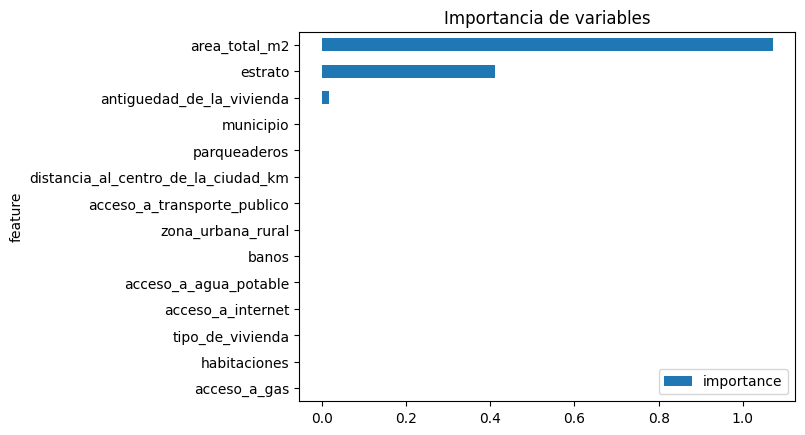

In [51]:
import matplotlib.pyplot as plt

df_importance.sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance"
)

plt.title("Importancia de variables")
plt.show()

# ENTRENAR MODELO FINAL (con todos los datos)

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Definir pipeline (igual que antes)
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

# Entrenar con TODOS los datos
model.fit(X, y)

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# GUARDAR CON PICKLE (.pkl)

import pickle

with open("modelo.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
# CARGAR EL MODELO PICKLE

with open("modelo.pkl", "rb") as f:
    modelo_cargado = pickle.load(f)

In [ ]:
#GUARDAR CON JOBLIB (.joblib)

import joblib

joblib.dump(model, "modelo.joblib")

In [ ]:
# CARGAR EL MODELO JOBLIB

modelo_cargado = joblib.load("modelo.joblib")

In [68]:
#from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import joblib
from pathlib import Path

# =========================
# PIPELINE
# =========================
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

# =========================
# ENTRENAMIENTO FINAL
# =========================
model.fit(X, y)

# Carpeta donde quieres guardar
ruta = Path("/Users/duvancatano/Documents/Data_Analytics_UdeA/ml-project/models")

# Crear carpeta si no existe
ruta.mkdir(parents=True, exist_ok=True)

# =========================
# GUARDAR MODELO
# =========================
joblib.dump(model,ruta / "model_linear_regression.joblib")

# =========================
# GUARDAR FEATURES (CLAVE 🔥)
# =========================
joblib.dump(X.columns.tolist(), ruta / "features_linear_regression.joblib")

['/Users/duvancatano/Documents/Data_Analytics_UdeA/ml-project/models/features_linear_regression.joblib']